<a href="https://colab.research.google.com/github/briannasancheztop/ADS505_Consumerbehavior/blob/main/ADS505_Group_Project_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#Brianna Sanchez and Alexander Zhuk

In [ ]:
%pip install dmba
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegressionCV
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, precision_score, recall_score

from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import RandomForestClassifier

import matplotlib.pylab as plt
import dmba
from dmba import plotDecisionTree, gainsChart, liftChart
from dmba import classificationSummary, regressionSummary
%matplotlib inline

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 70.7 MB/s eta 0:00:00
Colab environment detected.


In [ ]:
data = pd.read_csv('shopping_behavior_updated.csv')

In [ ]:
data.head(5)

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,Yes,31,PayPal,Annually


In [ ]:
print("Dataset shape:", data.shape)

Dataset shape: (3900, 18)


In [ ]:
print("Number of records:", len(data))

Number of records: 3900


In [ ]:
print("Number of variables:", len(data.columns))

Number of variables: 18


In [ ]:
print("Variable names:", data.columns.tolist())

Variable names: ['Customer ID', 'Age', 'Gender', 'Item Purchased', 'Category', 'Purchase Amount (USD)', 'Location', 'Size', 'Color', 'Season', 'Review Rating', 'Subscription Status', 'Shipping Type', 'Discount Applied', 'Promo Code Used', 'Previous Purchases', 'Payment Method', 'Frequency of Purchases']


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Customer ID             3900 non-null   int64  
 1   Age                     3900 non-null   int64  
 2   Gender                  3900 non-null   object 
 3   Item Purchased          3900 non-null   object 
 4   Category                3900 non-null   object 
 5   Purchase Amount (USD)   3900 non-null   int64  
 6   Location                3900 non-null   object 
 7   Size                    3900 non-null   object 
 8   Color                   3900 non-null   object 
 9   Season                  3900 non-null   object 
 10  Review Rating           3900 non-null   float64
 11  Subscription Status     3900 non-null   object 
 12  Shipping Type           3900 non-null   object 
 13  Discount Applied        3900 non-null   object 
 14  Promo Code Used         3900 non-null   

In [ ]:
print(data.describe())

       Customer ID          Age  Purchase Amount (USD)  Review Rating  \
count  3900.000000  3900.000000            3900.000000    3900.000000   
mean   1950.500000    44.068462              59.764359       3.749949   
std    1125.977353    15.207589              23.685392       0.716223   
min       1.000000    18.000000              20.000000       2.500000   
25%     975.750000    31.000000              39.000000       3.100000   
50%    1950.500000    44.000000              60.000000       3.700000   
75%    2925.250000    57.000000              81.000000       4.400000   
max    3900.000000    70.000000             100.000000       5.000000   

       Previous Purchases  
count         3900.000000  
mean            25.351538  
std             14.447125  
min              1.000000  
25%             13.000000  
50%             25.000000  
75%             38.000000  
max             50.000000  


In [ ]:
print(data.isnull().values.any()) #nulls
print(data.duplicated().sum()) #duplicates
data.columns = data.columns.str.strip().str.lower().str.replace(" ", "_") #python language to remove spaces with _

False
0


In [ ]:
#Feature Engineering
#Dropping irrelevant columns, encoding categorical variables
data = data.drop(columns=['color','location','item_purchased','customer_id'])
data = pd.get_dummies(data, columns=['gender','category','size','season','subscription_status','discount_applied',
                'promo_code_used', 'payment_method','shipping_type'])
freq_mapping = {
    'Every 3 Months': 'Quarterly',
    'Bi-Weekly': 'Fortnightly'
}
data['frequency_of_purchases'] = data['frequency_of_purchases'].replace(freq_mapping)
freq_order = {
    'Weekly': 6,
    'Fortnightly': 5,
    'Monthly': 4,
    'Quarterly': 3,
    'Annually': 2
}
data['frequency_numeric'] = data['frequency_of_purchases'].map(freq_order)

data = data.drop(columns=['frequency_of_purchases'])

In [ ]:
data.head(10)

,age,purchase_amount_(usd),review_rating,previous_purchases,gender_Female,gender_Male,category_Accessories,category_Clothing,category_Footwear,category_Outerwear,...,payment_method_Debit Card,payment_method_PayPal,payment_method_Venmo,shipping_type_2-Day Shipping,shipping_type_Express,shipping_type_Free Shipping,shipping_type_Next Day Air,shipping_type_Standard,shipping_type_Store Pickup,frequency_numeric
0,55,53,3.1,14,False,True,False,True,False,False,...,False,False,True,False,True,False,False,False,False,5
1,19,64,3.1,2,False,True,False,True,False,False,...,False,False,False,False,True,False,False,False,False,5
2,50,73,3.1,23,False,True,False,True,False,False,...,False,False,False,False,False,True,False,False,False,6
3,21,90,3.5,49,False,True,False,False,True,False,...,False,True,False,False,False,False,True,False,False,6
4,45,49,2.7,31,False,True,False,True,False,False,...,False,True,False,False,False,True,False,False,False,2
5,46,20,2.9,14,False,True,False,False,True,False,...,False,False,True,False,False,False,False,True,False,6
6,63,85,3.2,49,False,True,False,True,False,False,...,False,False,False,False,False,True,False,False,False,3
7,27,34,3.2,19,False,True,False,True,False,False,...,False,False,False,False,False,True,False,False,False,6
8,26,97,2.6,8,False,True,False,False,False,True,...,False,False,True,False,True,False,False,False,False,2
9,57,31,4.8,4,False,True,True,False,False,False,...,False,False,False,True,False,False,False,False,False,3


In [ ]:
#Partitioning data 60% training and 40% validation
X = data.drop(columns=['purchase_amount_(usd)'])
threshold = data['purchase_amount_(usd)'].quantile(0.75)  # Top 25% as high-value
y = (data['purchase_amount_(usd)'] >= threshold).astype(int)
# Dropping column purchase_amount_(usd) in X
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.4, random_state = 42)
#Performed split for training and test sets
scaler = StandardScaler()
#Created a StandardScaler object
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
# Scaling only numeric features
print(X_train.shape, y_train.shape)

(2340, 36) (2340,)


In [ ]:
logit_full = LogisticRegressionCV(penalty="l2", cv=5,solver='lbfgs',max_iter=500, class_weight='balanced')
#Created cross-validated logistic regression with balanced classes
#Applid L2 regularization (Ridge)
#Applied 5-fold cross-validation
#Used lbfgs to find model coeficients
#Set maximum number of iterations to 500
logit_full.fit(X_train_scaled, y_train)
#Trained logistic regression model on scaled data

LogisticRegressionCV(class_weight='balanced', cv=5, max_iter=500)

In [ ]:

#Evaluating which variables impact purchase amount the most
pd.set_option('display.width', 95)
pd.set_option('display.precision',3)
pd.set_option('display.max_columns', 33)
print('intercept ', logit_full.intercept_[0], '\n')
# could use display() to present this cleaner
#Set pandas display options and printed logistic regression intercept
print(pd.DataFrame({'coeff': logit_full.coef_[0]}, index=X.columns).transpose())
pd.reset_option('display.width')
pd.reset_option('display.precision')
pd.reset_option('display.max_columns')
#Displayed model coefficients in DataFrame, reset display options

intercept  -0.006337437215886623 

         age  review_rating  previous_purchases  gender_Female  gender_Male  \
coeff  0.005          0.026               0.007      6.477e-04   -6.477e-04   

       category_Accessories  category_Clothing  category_Footwear  category_Outerwear  \
coeff                -0.005              0.001              0.008              -0.004   

       size_L  size_M  size_S  size_XL  season_Fall  season_Spring  season_Summer  ...  \
coeff  -0.025   0.019  -0.003    0.008         0.03         -0.017         -0.011  ...   

       discount_applied_Yes  promo_code_used_No  promo_code_used_Yes  \
coeff                -0.005               0.005               -0.005   

       payment_method_Bank Transfer  payment_method_Cash  payment_method_Credit Card  \
coeff                        -0.021               -0.032                       0.009   

       payment_method_Debit Card  payment_method_PayPal  payment_method_Venmo  \
coeff                      0.032           

In [ ]:
y_pred = logit_full.predict(X_test_scaled)
logit_full_accuracy = accuracy_score(y_test, y_pred)
logit_full_report = classification_report(y_test, y_pred)
logit_full_precision = precision_score(y_test, y_pred)
logit_full_recall = recall_score(y_test, y_pred)
print("Logistic Regression Accuracy:", logit_full_accuracy)
print("Logistic Regression Precision", logit_full_precision)
print("Logistic Regression Report:", logit_full_report)
print("Logistic Regression Recall:", logit_full_recall)
#Calculated predictions and performance metrics for logistic regression

Logistic Regression Accuracy: 0.5147435897435897
Logistic Regression Precision 0.2465564738292011
Logistic Regression Report:               precision    recall  f1-score   support

           0       0.75      0.53      0.62      1171
           1       0.25      0.46      0.32       389

    accuracy                           0.51      1560
   macro avg       0.50      0.50      0.47      1560
weighted avg       0.62      0.51      0.55      1560

Logistic Regression Recall: 0.4601542416452442


In [ ]:
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)
#Printed confusion matrix

Confusion Matrix:
[[624 547]
 [210 179]]


In [ ]:
#Now looking into Random Forest Model
randomforest = RandomForestClassifier(n_estimators=400,
max_depth=3,
class_weight={0: 1, 1: 3}, # boost weight 3x for high-value customers
random_state = 42)
randomforest.fit(X_train, y_train)
y_pred_randomforest = randomforest.predict(X_test)
randomforest_accuracy = accuracy_score(y_test, y_pred_randomforest)
randomforest_full_report = classification_report(y_test, y_pred_randomforest)
rf_full_precision = precision_score(y_test, y_pred_randomforest)
rf_full_recall = recall_score(y_test, y_pred_randomforest)
print("Random Forest Accuracy:", randomforest_accuracy)
print("Random Forest Report:", randomforest_full_report)
print("RF Precision", rf_full_precision)
print("RF Recall:", rf_full_recall)

Random Forest Accuracy: 0.5506410256410257
Random Forest Report:               precision    recall  f1-score   support

           0       0.76      0.59      0.66      1171
           1       0.26      0.44      0.33       389

    accuracy                           0.55      1560
   macro avg       0.51      0.51      0.49      1560
weighted avg       0.63      0.55      0.58      1560

RF Precision 0.2607361963190184
RF Recall: 0.4370179948586118


In [ ]:
cm = confusion_matrix(y_test, y_pred_randomforest)
print("Confusion Matrix:")
print(cm)
#Printed Confusion matrix

Confusion Matrix:
[[689 482]
 [219 170]]


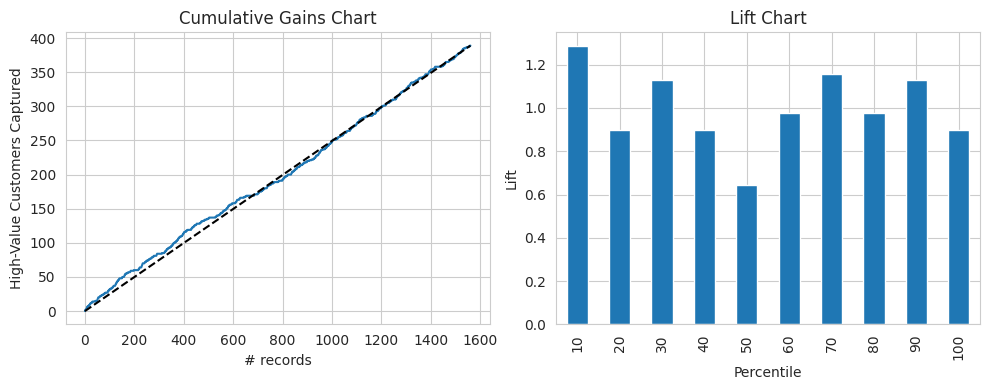

In [ ]:
y_pred_proba = logit_full.predict_proba(X_test_scaled)[:, 1]
#Got predicted probabilities for positive class only
score_df = pd.DataFrame({'Actual': y_test, 'Probability': y_pred_proba})
#Created DataFrame with actual values and probabilities
score_df_sorted = score_df.sort_values('Probability', ascending=False)
#Sorted DataFrame by probability in descending order
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10, 4))
#Created subplot figure with 2 columns, specified size.
ax = gainsChart(score_df_sorted['Actual'], ax=axes[0])
#Ploted gains chart using actual values on first subplot
ax.set_ylabel('High-Value Customers Captured')
#Set y-axis label Percentage of High-Value Customers Captured
ax.set_title('Cumulative Gains Chart')
#Set subplot title to Cumulative Gains Chart
ax = liftChart(score_df_sorted['Actual'], ax=axes[1], labelBars=False)
#Plotted lift chart on second subplot without bar labels
ax.set_ylabel('Lift')
#Set y-axis label to Lift
ax.set_title('Lift Chart')
#Set x-axis to Lift Chart
plt.tight_layout()
plt.show()
#Plotted graphs

In [ ]:
score_df_sorted

,Actual,Probability
1965,1,0.573248
2066,1,0.566022
2915,0,0.565293
3617,0,0.562310
1818,0,0.561685
...,...,...
3049,0,0.438197
1377,0,0.437547
2499,0,0.434955
1027,1,0.424418


In [ ]:
# Edit: collapse one-hot columns back to a single label
def collapse_one_hot(df, prefix):
    cols = [c for c in df.columns if c.lower().startswith(prefix.lower() + '_')]
    if not cols:
        return None
    vals = df[cols]
    label_map = {c: c.split('_', 1)[1] for c in cols}   # category_Clothing -> Clothing
    long = vals.reset_index().melt(id_vars='index', var_name='col', value_name='val')
    long = long[long['val'] == 1]
    picked = long.sort_values(['index','col']).drop_duplicates('index')\
                 .set_index('index')['col'].map(label_map)
    return picked.reindex(df.index)

# Edit: get binary from one-hots or fallback text
def binary_from_onehot_or_text(df, yes_col, no_col=None, text_col=None):
    if yes_col in df.columns:
        return df[yes_col].astype(int)
    if text_col and text_col in df.columns:
        return df[text_col].astype(str).str.strip().str.lower().isin(['yes','y','true','1']).astype(int)
    if no_col in df.columns:
        return (1 - df[no_col].astype(int)).clip(0,1)
    return pd.Series(np.nan, index=df.index)


# Coerce numerics used later
for c in ['purchase_amount_(usd)', 'age', 'review_rating', 'previous_purchases', 'frequency_numeric']:
    if c in data.columns:
        data[c] = pd.to_numeric(data[c], errors='coerce')

# Channel from shipping_type 'pickup' - In-Store; else Online
if 'shipping_type' in data.columns:
    st = data['shipping_type'].astype(str).str.lower()
    data['Channel'] = np.where(st.str.contains('pickup'), 'In-Store', 'Online')
else:
    data['Channel'] = 'Online'  # fallback

# Age cohorts
data['Age Cohort'] = pd.cut(
    data['age'],
    bins=[0,24,34,44,54,64,np.inf],
    labels=['<25','25-34','35-44','45-54','55-64','65+'],
    include_lowest=True
)

# Review buckets
data['Review Bucket'] = pd.cut(
    data['review_rating'],
    bins=[-np.inf,3,4,np.inf],
    labels=['Low (<3)','Mid (3-4]','High (>4)']
)

# Binary flags (prefer one-hot form)
data['Is Subscriber']   = binary_from_onehot_or_text(data, 'subscription_status_Yes', 'subscription_status_No', 'subscription_status')
data['Discount Flag']   = binary_from_onehot_or_text(data, 'discount_applied_Yes',    'discount_applied_No',    'discount_applied')
data['Promo Code Flag'] = binary_from_onehot_or_text(data, 'promo_code_used_Yes',     'promo_code_used_No',     'promo_code_used')

# Category and Payment method reconstructed from one-hots
cat_series = collapse_one_hot(data, 'category')
data['Category'] = cat_series if cat_series is not None else data.get('Category')

pay_series = collapse_one_hot(data, 'payment_method')
data['Payment Method'] = pay_series if pay_series is not None else data.get('Payment Method')


In [ ]:
# Edit previous code for appropriate Channel from shipping_type:
# 'pickup' → In-Store; all else → Online
if 'shipping_type' in data.columns:
    st = data['shipping_type'].astype(str).str.lower()
    data['Channel'] = np.where(st.str.contains('pickup', na=False), 'In-Store', 'Online')

# If lowercase version doesn't exist but one-hot or title-case does
elif 'Shipping Type' in data.columns:
    st = data['Shipping Type'].astype(str).str.lower()
    data['Channel'] = np.where(st.str.contains('pickup', na=False), 'In-Store', 'Online')

# Fallback using one-hot encoded flag if text column isn't found
elif 'shipping_type_Store Pickup' in data.columns:
    data['Channel'] = np.where(data['shipping_type_Store Pickup'] == True, 'In-Store', 'Online')

else:
    data['Channel'] = 'Online'  # final fallback if none found

print("Channel value counts:\n", data['Channel'].value_counts())

Channel value counts:
 Channel
Online      3250
In-Store     650
Name: count, dtype: int64



Age x Channel (Counts)
 Channel     In-Store  Online
Age Cohort                  
<25               82     404
25-34            124     631
35-44            136     593
45-54            132     620
55-64            115     636
65+               61     366

Age x Channel (Row %)
 Channel     In-Store  Online
Age Cohort                  
<25             16.9    83.1
25-34           16.4    83.6
35-44           18.7    81.3
45-54           17.6    82.4
55-64           15.3    84.7
65+             14.3    85.7


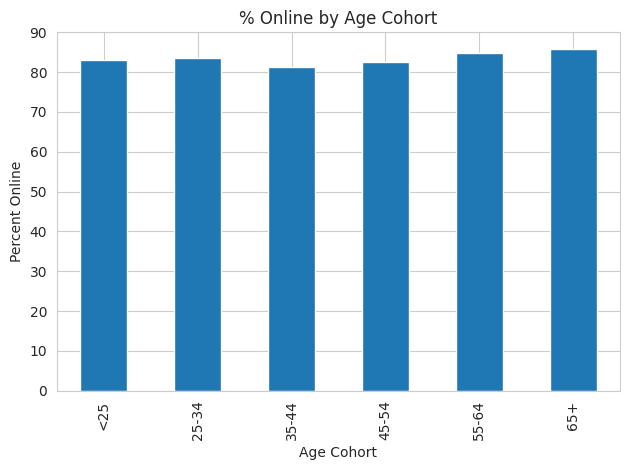

In [ ]:
#Age × Channel (counts & row % + chart)
age_ct = pd.crosstab(data['Age Cohort'], data['Channel']) #contigency table
age_rowpct = (age_ct.div(age_ct.sum(1), 0) * 100).round(1) #converting percentages in each row
print("\nAge x Channel (Counts)\n", age_ct)
print("\nAge x Channel (Row %)\n", age_rowpct)

plt.figure()
((age_ct.get('Online', 0) / age_ct.sum(1)) * 100).plot(kind='bar')
plt.title('% Online by Age Cohort'); plt.xlabel('Age Cohort'); plt.ylabel('Percent Online')
plt.tight_layout(); plt.show()




Category x Channel (Counts)
 Channel      In-Store  Online
Category                     
Accessories       217    1023
Clothing          282    1455
Footwear           98     501
Outerwear          53     271

Category Share within Channel (%)
 Channel      In-Store  Online
Accessories       NaN     NaN
Clothing          NaN     NaN
Footwear          NaN     NaN
In-Store          NaN     NaN
Online            NaN     NaN
Outerwear         NaN     NaN


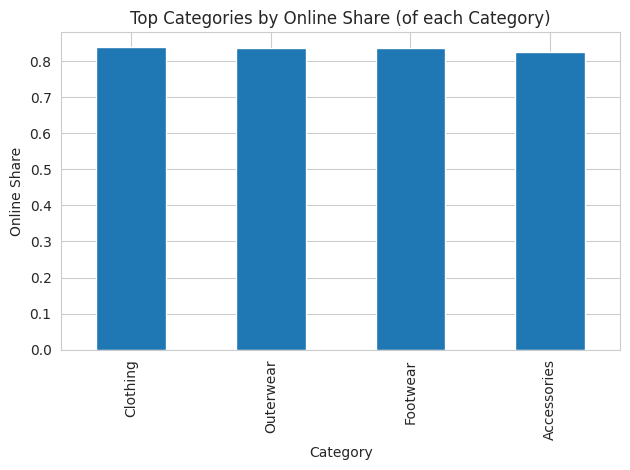

In [ ]:
#Category mix by Channel)
cat_ct = pd.crosstab(data['Category'], data['Channel']) #count table of how many purchases were made per category × channel.
cat_share = (cat_ct.div(cat_ct.sum(0), 0) * 100).round(1) #what % of each channel comes from each category
print("\nCategory x Channel (Counts)\n", cat_ct)
print("\nCategory Share within Channel (%)\n", cat_share)

top_online_share = (cat_ct.get('Online', 0) / cat_ct.sum(1)).fillna(0).sort_values(ascending=False).head(8) #Calculates, for each category, % of its sales that happen Online
plt.figure()
top_online_share.plot(kind='bar')
plt.title('Top Categories by Online Share (of each Category)')
plt.xlabel('Category'); plt.ylabel('Online Share')
plt.tight_layout(); plt.show()


/tmp/ipython-input-1464050742.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  review_grp = data.groupby('Review Bucket').agg(



Review Bucket vs Behavior
                avg_purchase  avg_prev_purchases     n
Review Bucket                                        
Low (<3)              58.94               25.19   847
Mid (3-4]             59.29               25.44  1590
High (>4)             60.75               25.35  1463

Subscription x Channel vs Behavior
    Is Subscriber   Channel  avg_purchase  avg_prev_purchases     n
0              0  In-Store         60.80               25.10   460
1              0    Online         59.69               25.08  2387
2              1  In-Store         57.71               24.08   190
3              1    Online         59.88               26.53   863


<Figure size 640x480 with 0 Axes>

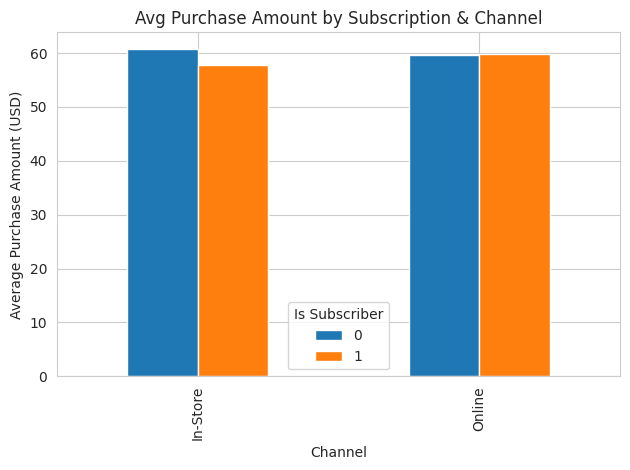

In [ ]:
# Review buckets vs spend & repeat
review_grp = data.groupby('Review Bucket').agg(
    avg_purchase=('purchase_amount_(usd)', 'mean'),
    avg_prev_purchases=('previous_purchases', 'mean'),
    n=('age', 'count')
).round(2)
print("\nReview Bucket vs Behavior\n", review_grp)

# Subscriber vs non-subscriber by channel
sub_grp = data.groupby(['Is Subscriber', 'Channel']).agg(
    avg_purchase=('purchase_amount_(usd)', 'mean'),
    avg_prev_purchases=('previous_purchases', 'mean'),
    n=('age', 'count')
).round(2).reset_index()
print("\nSubscription x Channel vs Behavior\n", sub_grp)

# Chart
sub_pivot = sub_grp.pivot(index='Channel', columns='Is Subscriber', values='avg_purchase')
plt.figure()
sub_pivot.plot(kind='bar')
plt.title('Avg Purchase Amount by Subscription & Channel')
plt.xlabel('Channel'); plt.ylabel('Average Purchase Amount (USD)')
plt.tight_layout(); plt.show()


In [ ]:
# payment methos
pay_channel = pd.crosstab(data['Payment Method'], data['Channel'])
pay_age = pd.crosstab(data['Payment Method'], data['Age Cohort'])
print("\nPayment Method x Channel (Counts)\n", pay_channel)
print("\nPayment Method x Age Cohort (Counts)\n", pay_age)



Payment Method x Channel (Counts)
 Channel               In-Store  Online
Payment Method                        
method_Bank Transfer       112     500
method_Cash                119     551
method_Credit Card         104     567
method_Debit Card          105     531
method_PayPal              103     574
method_Venmo               107     527

Payment Method x Age Cohort (Counts)
 Age Cohort            <25  25-34  35-44  45-54  55-64  65+
Payment Method                                            
method_Bank Transfer   83    123    104    121    101   80
method_Cash            93    129    110    127    135   76
method_Credit Card     81    129    128    116    135   82
method_Debit Card      75    118    133    124    120   66
method_PayPal          77    124    132    148    136   60
method_Venmo           77    132    122    116    124   63



Promotion Effect (Discount vs No Discount)
                avg_purchase     n
Discount Flag                    
0                     60.13  2223
1                     59.28  1677

Promo Code Usage x Channel (Counts)
 Channel          In-Store  Online
Promo Code Flag                  
0                     365    1858
1                     285    1392

Promo Code Usage Rate within Channel (%)
 Channel   In-Store  Online
0              NaN     NaN
1              NaN     NaN
In-Store       NaN     NaN
Online         NaN     NaN


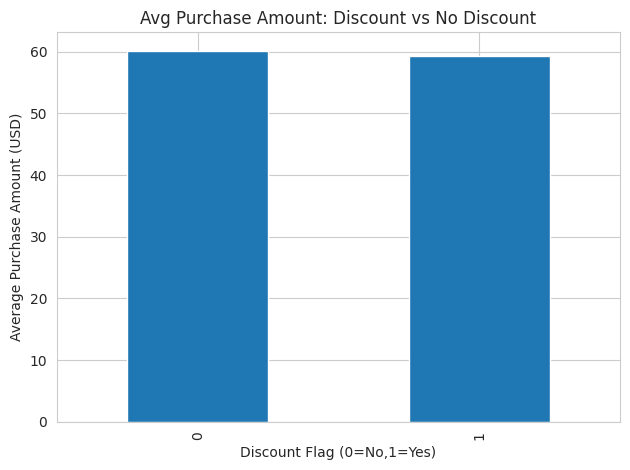

In [ ]:
# Average spend with vs. without discount (Discount Flag is 1 = discount applied, 0 = no discount.)
promo_effect = data.groupby('Discount Flag').agg(
    avg_purchase=('purchase_amount_(usd)', 'mean'),
    n=('age', 'count')
).round(2)
print("\nPromotion Effect (Discount vs No Discount)\n", promo_effect)

promo_code_ct = pd.crosstab(data['Promo Code Flag'], data['Channel']) #Promo Code Flag = 1 if promo used, 0 otherwise.
promo_code_rate = (promo_code_ct.div(promo_code_ct.sum(0), 0) * 100).round(1)
print("\nPromo Code Usage x Channel (Counts)\n", promo_code_ct)
print("\nPromo Code Usage Rate within Channel (%)\n", promo_code_rate)

plt.figure()
promo_effect['avg_purchase'].plot(kind='bar')
plt.title('Avg Purchase Amount: Discount vs No Discount')
plt.xlabel('Discount Flag (0=No,1=Yes)'); plt.ylabel('Average Purchase Amount (USD)')
plt.tight_layout(); plt.show()


In [ ]:
#should we move this up to the top?
# describe / value counts
print(data['purchase_amount_(usd)'].describe())
print(data['review_rating'].value_counts())


count    3900.000000
mean       59.764359
std        23.685392
min        20.000000
25%        39.000000
50%        60.000000
75%        81.000000
max       100.000000
Name: purchase_amount_(usd), dtype: float64
review_rating
3.4    182
4.0    181
4.6    174
4.2    171
2.9    170
4.9    166
3.9    163
3.0    162
2.6    159
4.4    158
3.1    157
3.5    156
3.7    156
2.7    154
3.3    152
3.2    152
3.6    149
4.1    148
4.7    148
4.3    147
4.8    144
3.8    142
4.5    139
2.8    136
5.0     68
2.5     66
Name: count, dtype: int64


In [ ]:
# are results statistically significant, or just noise?

from scipy.stats import chi2_contingency, ttest_ind


#Chi-Square Tests (categorical relationships)

def chi_square_test(table, name="Chi-Square Test"):
    chi2, p, dof, exp = chi2_contingency(table)
    print(f"\n{name}")
    print("Chi-square:", round(chi2, 3), " | dof:", dof, " | p-value:", round(p, 4))
    return p

#Age Cohort × Channel
chi_square_test(pd.crosstab(data['Age Cohort'], data['Channel']), "Age Cohort × Channel")

#Category × Channel
chi_square_test(pd.crosstab(data['Category'], data['Channel']), "Category × Channel")

#Promo Code × Channel
chi_square_test(pd.crosstab(data['Promo Code Flag'], data['Channel']), "Promo Code × Channel")


#t-tests (mean spend differences)
def t_test_groups(series, group, g1=1, g0=0, label="Group"):
    """Run t-test comparing spend across two groups (1 vs 0)."""
    s1 = series[group==g1]
    s0 = series[group==g0]
    t, p = ttest_ind(s1, s0, equal_var=False, nan_policy='omit')
    print(f"\n{label}: mean spend {g1}={s1.mean():.2f}, {g0}={s0.mean():.2f}")
    print(f"t={t:.3f}, p={p:.4f}, N={len(s1)+len(s0)}")
    return p

#Subscribers vs Non
t_test_groups(data['purchase_amount_(usd)'], data['Is Subscriber'], label="Subscribers vs Non")

#Discount vs No Discount
t_test_groups(data['purchase_amount_(usd)'], data['Discount Flag'], label="Discount vs No Discount")

#Promo Code vs No Promo Code
t_test_groups(data['purchase_amount_(usd)'], data['Promo Code Flag'], label="Promo Code vs No Promo Code")

#Age Cohort × Channel: Avg purchase
age_channel_table = data.groupby(['Age Cohort','Channel'])['purchase_amount_(usd)'].mean().unstack()
print("\nAvg Purchase Amount by Age Cohort × Channel\n", age_channel_table.round(2))

#Category × Channel: Avg purchase
cat_channel_table = data.groupby(['Category','Channel'])['purchase_amount_(usd)'].mean().unstack()
print("\nAvg Purchase Amount by Category × Channel\n", cat_channel_table.round(2))

#Discount × Channel
disc_channel_table = data.groupby(['Discount Flag','Channel'])['purchase_amount_(usd)'].mean().unstack()
print("\nAvg Purchase Amount by Discount Flag × Channel\n", disc_channel_table.round(2))

#Subscribers × Review Bucket
sub_review_table = data.groupby(['Is Subscriber','Review Bucket'])['purchase_amount_(usd)'].mean().unstack()
print("\nAvg Purchase Amount by Subscription × Review Bucket\n", sub_review_table.round(2))



Age Cohort × Channel
Chi-square: 5.283  | dof: 5  | p-value: 0.3824

Category × Channel
Chi-square: 0.916  | dof: 3  | p-value: 0.8216

Promo Code × Channel
Chi-square: 0.188  | dof: 1  | p-value: 0.6643

Subscribers vs Non: mean spend 1=59.49, 0=59.87
t=-0.440, p=0.6603, N=3900

Discount vs No Discount: mean spend 1=59.28, 0=60.13
t=-1.112, p=0.2661, N=3900

Promo Code vs No Promo Code: mean spend 1=59.28, 0=60.13
t=-1.112, p=0.2661, N=3900

Avg Purchase Amount by Age Cohort × Channel
 Channel     In-Store  Online
Age Cohort                  
<25            59.17   60.41
25-34          57.37   60.68
35-44          61.85   59.11
45-54          60.45   60.31
55-64          60.96   58.31
65+            58.43   59.92

Avg Purchase Amount by Category × Channel
 Channel      In-Store  Online
Category                     
Accessories     59.52   59.91
Clothing        58.24   60.37
Footwear        61.67   59.98
Outerwear       66.94   55.26

Avg Purchase Amount by Discount Flag × Channel
 Ch

/tmp/ipython-input-2691225712.py:44: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_channel_table = data.groupby(['Age Cohort','Channel'])['purchase_amount_(usd)'].mean().unstack()
/tmp/ipython-input-2691225712.py:56: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sub_review_table = data.groupby(['Is Subscriber','Review Bucket'])['purchase_amount_(usd)'].mean().unstack()


=== Total Spend and Percent Share by Channel ===
    Channel  purchase_amount_(usd)  Percent of Total
1    Online                 194150         83.297223
0  In-Store                  38931         16.702777


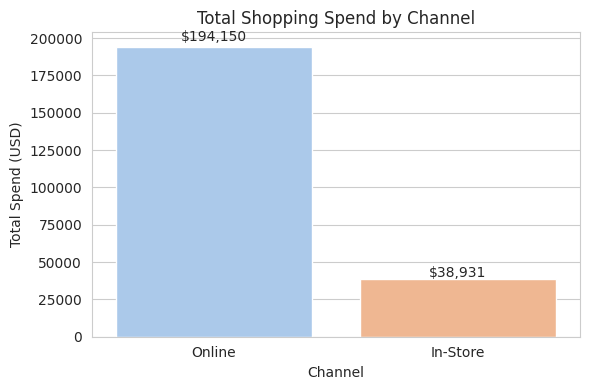

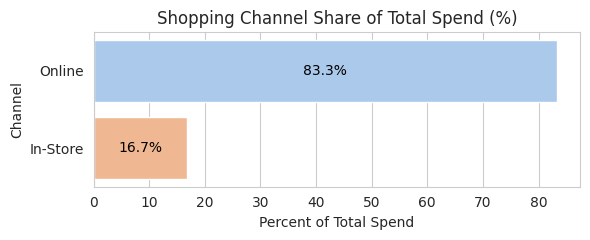

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

#Aggregate total spend per channel
channel_spend = (
    data.groupby('Channel')['purchase_amount_(usd)']
        .sum()
        .reset_index()
        .sort_values('purchase_amount_(usd)', ascending=False)
)

#Calculate each channel’s share of total
channel_spend['Percent of Total'] = (
    channel_spend['purchase_amount_(usd)'] /
    channel_spend['purchase_amount_(usd)'].sum() * 100
)

print("=== Total Spend and Percent Share by Channel ===")
print(channel_spend)

#Column Chart
plt.figure(figsize=(6,4))
sns.barplot(
    x='Channel',
    y='purchase_amount_(usd)',
    data=channel_spend,
    hue='Channel',          # fixes seaborn palette warning
    palette='pastel',
    legend=False
)

# value labels
for i, val in enumerate(channel_spend['purchase_amount_(usd)']):
    plt.text(i, val + (val * 0.02), f"${val:,.0f}", ha='center', fontsize=10)

plt.title('Total Shopping Spend by Channel')
plt.xlabel('Channel')
plt.ylabel('Total Spend (USD)')
plt.tight_layout()
plt.show()

#Horizontal Percentage Bar Chart
plt.figure(figsize=(6,2.5))
sns.barplot(
    y='Channel',
    x='Percent of Total',
    data=channel_spend,
    palette='pastel',
    hue='Channel',
    legend=False
)

#percentage labels
for i, val in enumerate(channel_spend['Percent of Total']):
    plt.text(val / 2, i, f"{val:.1f}%", color='black', ha='center', va='center', fontsize=10)

plt.title('Shopping Channel Share of Total Spend (%)')
plt.xlabel('Percent of Total Spend')
plt.ylabel('Channel')
plt.tight_layout()
plt.show()


In [ ]:
import re
import numpy as np

# one-hot column for Store Pickup no matter how it's cased/spaced
def find_store_pickup_flag(df):
    for c in df.columns:
        norm = re.sub(r'[^a-z0-9]', '', c.lower())
        # match: shipping_type_store_pickup / store_pickup / shippingtypestorepickup
        if norm.endswith('shippingtypestorepickup') or norm.endswith('storepickup'):
            return c
    return None

flag_col = find_store_pickup_flag(data)
if flag_col is None:

    flag_col = 'shipping_type_Store Pickup' if 'shipping_type_Store Pickup' in data.columns else None

if flag_col is None:
    raise KeyError("Couldn't find a Store Pickup one-hot column. Print(data.columns) to inspect.")

# Channel from the one-hot column (True => In-Store, else Online)
data['Channel'] = np.where(data[flag_col].astype(bool), 'In-Store', 'Online')

print("Channel counts (from one-hot):")
print(data['Channel'].value_counts(dropna=False))



Channel counts (from one-hot):
Channel
Online      3250
In-Store     650
Name: count, dtype: int64


In [ ]:
#use spend column
spend_col = 'purchase_amount_(usd)' if 'purchase_amount_(usd)' in data.columns else 'Purchase Amount (USD)'
data[spend_col] = pd.to_numeric(data[spend_col], errors='coerce').fillna(0)

#category x Channel totals
cat_spend = (
    data.groupby(['Category', 'Channel'], as_index=False)[spend_col]
        .sum()
        .rename(columns={spend_col: 'Total Spend (USD)'})
)

#Top 5 per channel
top_online = (cat_spend.query("Channel == 'Online'")
              .sort_values('Total Spend (USD)', ascending=False).head(5))
top_store  = (cat_spend.query("Channel == 'In-Store'")
              .sort_values('Total Spend (USD)', ascending=False).head(5))

print("\nTop Online Categories by Spend\n", top_online)
print("\nTop In-Store Categories by Spend\n", top_store if not top_store.empty else "No In-Store rows / (Store Pickup) found")



Top Online Categories by Spend
       Category Channel  Total Spend (USD)
3     Clothing  Online              87840
1  Accessories  Online              61285
5     Footwear  Online              30049
7    Outerwear  Online              14976

Top In-Store Categories by Spend
       Category   Channel  Total Spend (USD)
2     Clothing  In-Store              16424
0  Accessories  In-Store              12915
4     Footwear  In-Store               6044
6    Outerwear  In-Store               3548


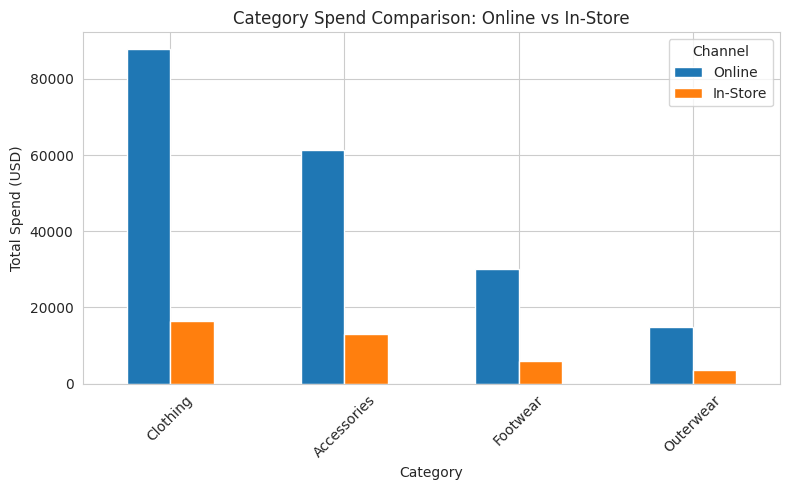

In [ ]:
#Online vs In-Store Spend per Category
#Pivot category spend into side-by-side format
pivot_spend = (
    cat_spend.pivot(index='Category', columns='Channel', values='Total Spend (USD)')
              .fillna(0)
              .sort_values('Online', ascending=False)
)

# bar chart
pivot_spend[['Online', 'In-Store']].plot(kind='bar', figsize=(8,5))
plt.title('Category Spend Comparison: Online vs In-Store')
plt.xlabel('Category')
plt.ylabel('Total Spend (USD)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


Average spend per transaction by channel:
     Channel  Average Spend (USD)
0  In-Store            59.893846
1    Online            59.738462


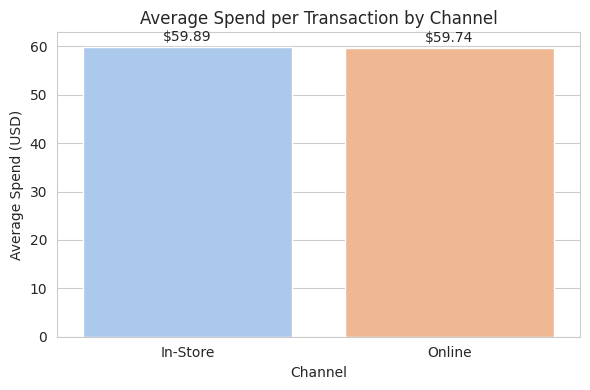

In [ ]:
#Average spend per transaction $
avg_spend = (
    data.groupby('Channel')['purchase_amount_(usd)']
        .mean()
        .reset_index()
        .rename(columns={'purchase_amount_(usd)': 'Average Spend (USD)'})
        .sort_values('Average Spend (USD)', ascending=False)
)

print("Average spend per transaction by channel:\n", avg_spend)

# Visualize
plt.figure(figsize=(6,4))
sns.barplot(
    x='Channel',
    y='Average Spend (USD)',
    data=avg_spend,
    hue='Channel',
    palette='pastel',
    legend=False
)

#Add value labels
for i, val in enumerate(avg_spend['Average Spend (USD)']):
    plt.text(i, val + (val * 0.02), f"${val:,.2f}", ha='center', fontsize=10)

plt.title('Average Spend per Transaction by Channel')
plt.xlabel('Channel')
plt.ylabel('Average Spend (USD)')
plt.tight_layout()
plt.show()


In [ ]:
!jupyter nbconvert --to html /content/ADS505_Group_Project_.ipynb

[NbConvertApp] Converting notebook /content/ADS505_Group_Project_.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 9 image(s).
[NbConvertApp] Writing 760313 bytes to /content/ADS505_Group_Project_.html


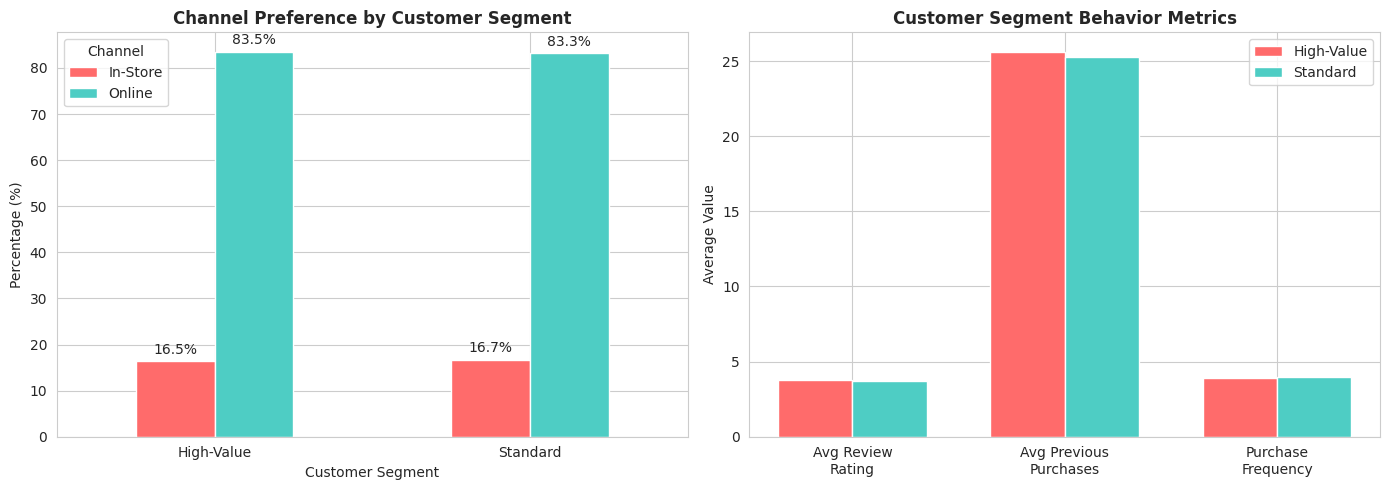


Segment Metrics:
                  review_rating  previous_purchases  frequency_numeric
Customer_Segment                                                      
High-Value                 3.78               25.63               3.94
Standard                   3.74               25.26               3.98


In [ ]:
# Set style
sns.set_style("whitegrid")

# Define high-value customers (top 25%)
threshold = data['purchase_amount_(usd)'].quantile(0.75)
data['Customer_Segment'] = np.where(
    data['purchase_amount_(usd)'] >= threshold,
    'High-Value',
    'Standard'
)

# Compare segments by channel
segment_channel = pd.crosstab(
    data['Customer_Segment'],
    data['Channel'],
    normalize='index'
) * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Channel preference by segment
segment_channel.plot(kind='bar', ax=axes[0], color=['#FF6B6B', '#4ECDC4'])
axes[0].set_title('Channel Preference by Customer Segment', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Customer Segment')
axes[0].set_ylabel('Percentage (%)')
axes[0].legend(title='Channel')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)

# Add value labels
for container in axes[0].containers:
    axes[0].bar_label(container, fmt='%.1f%%', padding=3)

# Average metrics comparison
segment_metrics = data.groupby('Customer_Segment').agg({
    'review_rating': 'mean',
    'previous_purchases': 'mean',
    'frequency_numeric': 'mean'
}).round(2)

x_pos = np.arange(len(segment_metrics.columns))
width = 0.35
high_val = segment_metrics.loc['High-Value'].values
std_val = segment_metrics.loc['Standard'].values

axes[1].bar(x_pos - width/2, high_val, width, label='High-Value', color='#FF6B6B')
axes[1].bar(x_pos + width/2, std_val, width, label='Standard', color='#4ECDC4')
axes[1].set_title('Customer Segment Behavior Metrics', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Average Value')
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(['Avg Review\nRating', 'Avg Previous\nPurchases', 'Purchase\nFrequency'])
axes[1].legend()

plt.tight_layout()
plt.show()

print("\nSegment Metrics:")
print(segment_metrics)